# Customer Segmentation Analysis

## Project Objective

The objective of this project is to segment e-commerce customers based on their purchasing behavior using clustering techniques. The analysis will identify different customer groups and help understand their purchasing patterns.

## Tools and Technologies

- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn
- Jupyter Notebook

## Analysis Covered

1. Data Loading and Inspection
2. Data Cleaning
3. Customer Behavioral Metrics
4. RFM Feature Creation
5. Feature Standardization
6. Elbow Method
7. K-Means Clustering
8. Cluster Visualization
9. Customer Segment Profiling
10. Marketing Actions for Each Segment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("../dataset/retail_sales_dataset.csv")

In [3]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [5]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [8]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [9]:
df['Date'] = pd.to_datetime(df['Date'])

In [10]:
reference_date = df['Date'].max() + pd.Timedelta(days=1)

print("Reference Date:", reference_date)

Reference Date: 2024-01-02 00:00:00


In [11]:
customer_data = df.groupby('Customer ID').agg(
    Recency=('Date', lambda x: (reference_date - x.max()).days),
    Frequency=('Transaction ID', 'count'),
    Monetary=('Total Amount', 'sum')
).reset_index()

customer_data.head()

,Customer ID,Recency,Frequency,Monetary
0,CUST001,39,1,150
1,CUST002,309,1,1000
2,CUST003,354,1,30
3,CUST004,226,1,500
4,CUST005,241,1,100


In [12]:
customer_data.describe()

,Recency,Frequency,Monetary
count,1000.000000,1000.0,1000.000000
mean,182.982000,1.0,456.000000
std,105.276773,0.0,559.997632
min,1.000000,1.0,25.000000
25%,90.000000,1.0,60.000000
50%,186.500000,1.0,135.000000
75%,269.000000,1.0,900.000000
max,366.000000,1.0,2000.000000


In [13]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Customer ID  1000 non-null   object
 1   Recency      1000 non-null   int64 
 2   Frequency    1000 non-null   int64 
 3   Monetary     1000 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 31.4+ KB


In [14]:
features = ['Recency', 'Frequency', 'Monetary']

scaler = StandardScaler()

customer_data_scaled = scaler.fit_transform(customer_data[features])

customer_data_scaled = pd.DataFrame(
    customer_data_scaled,
    columns=features
)

customer_data_scaled.head()

,Recency,Frequency,Monetary
0,-1.368336,0.0,-0.546704
1,1.197615,0.0,0.971919
2,1.625274,0.0,-0.761098
3,0.408823,0.0,0.078611
4,0.551375,0.0,-0.636035


In [15]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(customer_data_scaled)
    inertia.append(kmeans.inertia_)

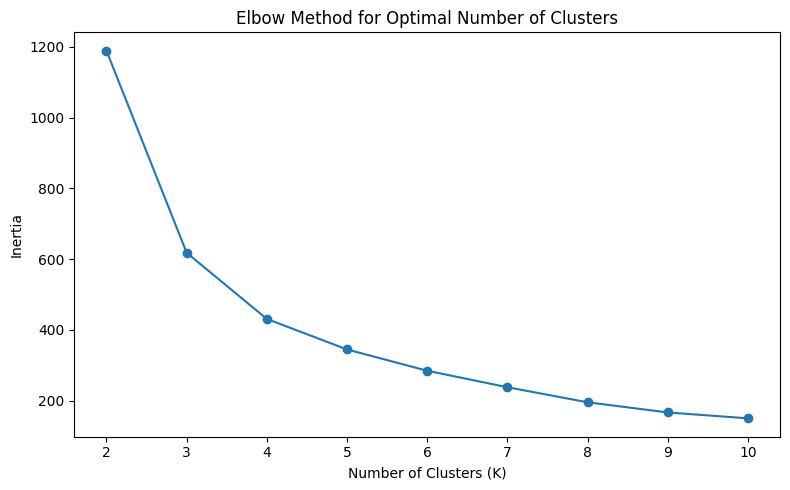

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker='o')

plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.tight_layout()
plt.show()

In [17]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

customer_data['Cluster'] = kmeans.fit_predict(customer_data_scaled)

customer_data.head()

,Customer ID,Recency,Frequency,Monetary,Cluster
0,CUST001,39,1,150,1
1,CUST002,309,1,1000,0
2,CUST003,354,1,30,2
3,CUST004,226,1,500,2
4,CUST005,241,1,100,2


In [18]:
cluster_counts = customer_data['Cluster'].value_counts().sort_index()

cluster_counts

Cluster
0    140
1    370
2    366
3    124
Name: count, dtype: int64

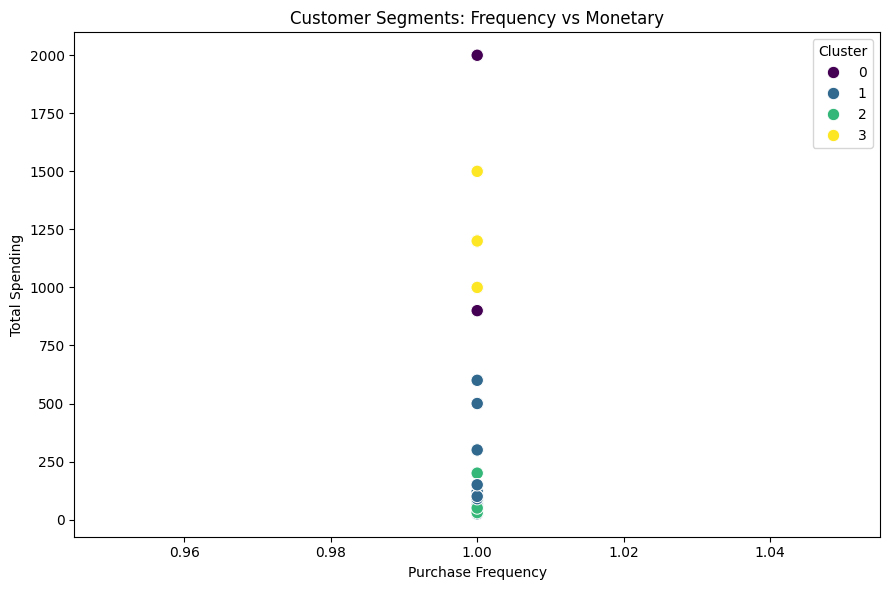

In [19]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=customer_data,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=80
)

plt.title('Customer Segments: Frequency vs Monetary')
plt.xlabel('Purchase Frequency')
plt.ylabel('Total Spending')
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()

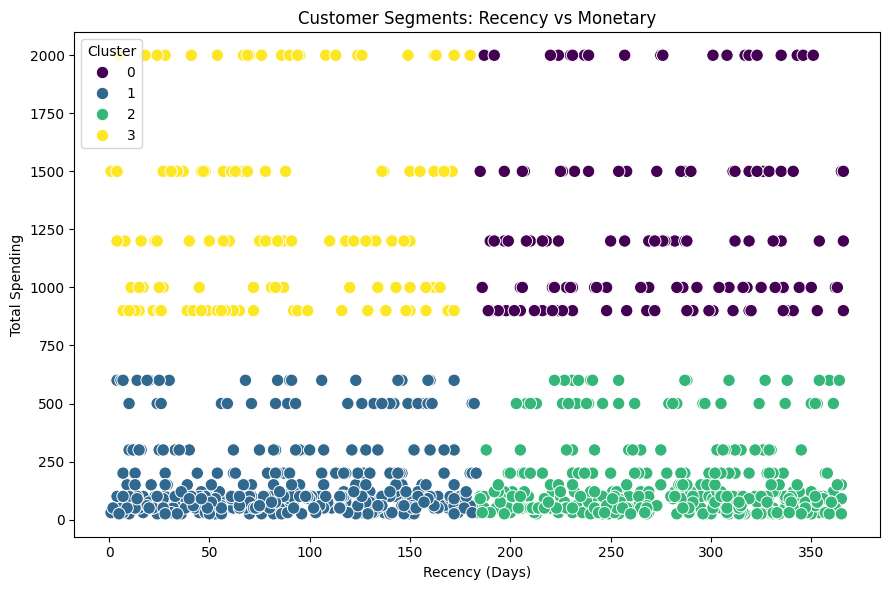

In [20]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=customer_data,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=80
)

plt.title('Customer Segments: Recency vs Monetary')
plt.xlabel('Recency (Days)')
plt.ylabel('Total Spending')
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()

In [21]:
cluster_profile = customer_data.groupby('Cluster')[features].mean().round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,270.52,1.0,1283.57
1,92.12,1.0,159.77
2,274.57,1.0,148.32
3,84.94,1.0,1313.71


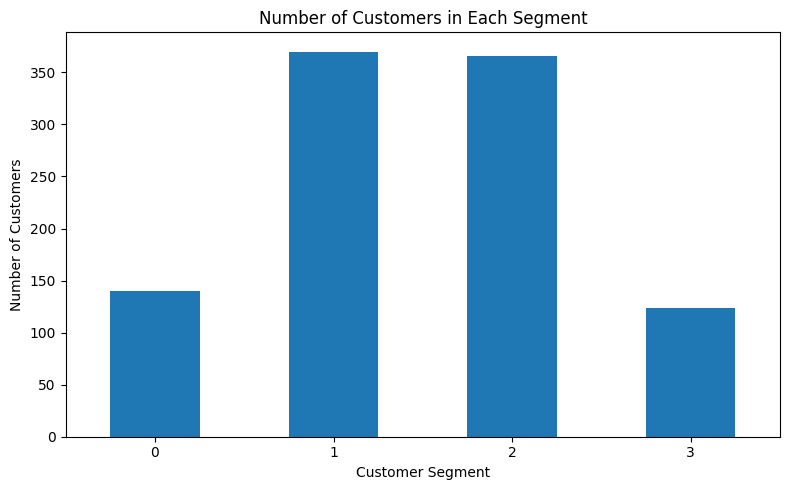

In [22]:
plt.figure(figsize=(8, 5))

cluster_counts.plot(kind='bar')

plt.title('Number of Customers in Each Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation

The chart shows the number of customers assigned to each customer segment. The segment sizes are different, indicating that some customer groups are more common than others.

In [23]:
cluster_summary = customer_data.groupby('Cluster').agg(
    Customers=('Customer ID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).round(2)

cluster_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,140,270.52,1.0,1283.57
1,370,92.12,1.0,159.77
2,366,274.57,1.0,148.32
3,124,84.94,1.0,1313.71


In [24]:
cluster_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,140,270.52,1.0,1283.57
1,370,92.12,1.0,159.77
2,366,274.57,1.0,148.32
3,124,84.94,1.0,1313.71


In [25]:
customer_data.to_csv(
    "../output/customer_segments.csv",
    index=False
)

In [26]:
cluster_summary.to_csv(
    "../output/cluster_summary.csv"
)

## Customer Segment Profiling

Based on the cluster summary:

- **Cluster 0:** 140 customers with relatively high recency and high average monetary value. These customers have spent significantly more but have not purchased recently.
- **Cluster 1:** 370 customers with relatively lower recency and low average monetary value. These customers are more recent but contribute comparatively less revenue.
- **Cluster 2:** 366 customers with high recency and low average monetary value. These customers appear less recently active and have relatively low spending.
- **Cluster 3:** 124 customers with the lowest average recency and the highest average monetary value. These customers are recently active and have high spending.

## Marketing Actions for Each Segment

| Cluster | Suggested Marketing Action |
|---|---|
| Cluster 0 | Use re-engagement campaigns and personalized offers to encourage previous high-spending customers to return. |
| Cluster 1 | Encourage repeat purchases through loyalty rewards, product recommendations, and targeted offers. |
| Cluster 2 | Use stronger re-engagement campaigns, discounts, and personalized promotions to bring inactive customers back. |
| Cluster 3 | Provide loyalty rewards, exclusive offers, premium services, and early access to retain these high-value active customers. |

## Conclusion

K-Means clustering was used to segment customers based on Recency, Frequency, and Monetary purchasing behavior.

The analysis produced four customer segments with different combinations of recency and spending. Cluster 3 contains recently active customers with the highest average monetary value, while Cluster 2 contains customers with relatively high recency and low spending.

One limitation of this dataset is that the average purchase frequency is 1.0 across all clusters. Therefore, Frequency does not provide meaningful separation between the segments. The resulting segmentation is mainly influenced by Recency and Monetary value.

These segments can help businesses design targeted retention, re-engagement, loyalty, and promotional strategies.

In [27]:
customer_data.isnull().sum()

Customer ID    0
Recency        0
Frequency      0
Monetary       0
Cluster        0
dtype: int64

In [28]:
customer_data.duplicated().sum()

np.int64(0)